<a href="https://colab.research.google.com/github/srijamaradana/MACHINE-LEARNING-ASSIGNMENTS/blob/main/K_NEAREST_NEIGHBOURS(EXP_9_6_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
data = pd.DataFrame({
    'Brightness': [40, 50, 60, 10, 70, 60, 25],
    'Saturation': [20, 50, 90, 25, 70, 10, 80],
    'Class': ['Red', 'Blue', 'Blue', 'Red',
              'Blue', 'Red', 'Blue']
})

print(data.shape)
data.head()

(7, 3)


,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue


In [3]:
data.isnull().sum()

,0
Brightness,0
Saturation,0
Class,0


In [4]:
le = LabelEncoder()

data['Class'] = le.fit_transform(data['Class'])

feature_cols = ['Brightness', 'Saturation']

x = data[feature_cols]
y = data['Class']

In [5]:
print(data)
print(le.classes_)

   Brightness  Saturation  Class
0          40          20      1
1          50          50      0
2          60          90      0
3          10          25      1
4          70          70      0
5          60          10      1
6          25          80      0
['Blue' 'Red']


In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3,
    random_state=0
)

display(
    x_train.shape,
    y_train.shape,
    x_test.shape,
    y_test.shape
)

(4, 2)

(4,)

(3, 2)

(3,)

In [7]:
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [9]:
results = []

for i in [1, 2, 3, 4]:

    model = KNeighborsClassifier(
        n_neighbors=i,
        metric='minkowski',
        p=2
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    Accuracy_score = metrics.accuracy_score(
        y_test,
        y_pred
    )

    results.append(Accuracy_score)

print("KNN [minkowski]")
print("Accuracy for different neighbors:")
print(results)

KNN [minkowski]
Accuracy for different neighbors:
[1.0, 1.0, 0.0, 0.0]


In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 5
Testing samples: 2


In [11]:
model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("KNN [minkowski, neighbor=5]")
print("Prediction:", y_pred)

KNN [minkowski, neighbor=5]
Prediction: [1 1]


In [12]:
conf_mat = metrics.confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(conf_mat)

Accuracy_score = metrics.accuracy_score(
    y_test,
    y_pred
)

print("Accuracy Score:", Accuracy_score)

print(
    "Accuracy in Percentage:",
    int(Accuracy_score * 100),
    "%"
)

print(
    metrics.classification_report(
        y_test,
        y_pred
    )
)

Confusion Matrix:
[[0 2]
 [0 0]]
Accuracy Score: 0.0
Accuracy in Percentage: 0 %
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

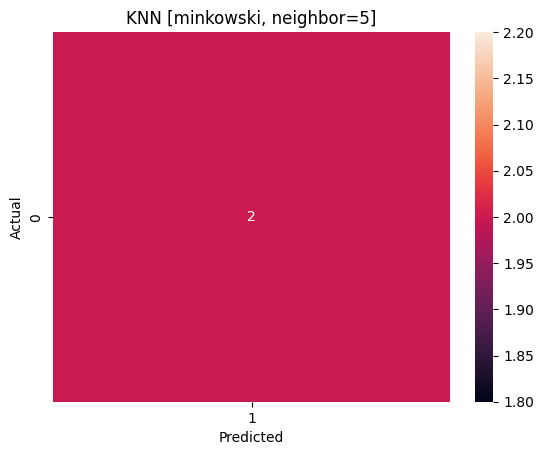

In [13]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(
    conf_mat,
    annot=True
).set(
    title='KNN [minkowski, neighbor=5]'
)

plt.show()

In [14]:
new_brightness = 55
new_saturation = 60

data['Distance'] = (
    (data['Brightness'] - new_brightness) ** 2 +
    (data['Saturation'] - new_saturation) ** 2
) ** 0.5

print(
    data[
        ['Brightness', 'Saturation', 'Class', 'Distance']
    ].sort_values('Distance')
)

   Brightness  Saturation  Class   Distance
1          50          50      0  11.180340
4          70          70      0  18.027756
2          60          90      0  30.413813
6          25          80      0  36.055513
0          40          20      1  42.720019
5          60          10      1  50.249378
3          10          25      1  57.008771


In [15]:
new_entry = [[55, 60]]

new_entry_scaled = sc.transform(new_entry)

prediction = model.predict(new_entry_scaled)

predicted_class = le.inverse_transform(prediction)

print("New Entry:", new_entry)
print("Predicted Class:", predicted_class[0])

New Entry: [[55, 60]]
Predicted Class: Red


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
